In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from scipy import stats

In [2]:
## 1. Data Loading & Initial Audit
df = pd.read_csv("customer_data_with_churn.csv")
df.head()

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          2000 non-null   str    
 1   Name                2000 non-null   str    
 2   Age                 2000 non-null   int64  
 3   Gender              2000 non-null   str    
 4   Annual_Income       2000 non-null   int64  
 5   Spending_Score      2000 non-null   int64  
 6   Membership_Level    2000 non-null   str    
 7   Purchase_Frequency  2000 non-null   float64
 8   Churn_Status        2000 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 140.8 KB


In [4]:
# There are no missing values in any column field
# now let's have a look at some stats of the data
df.describe(include = 'all')

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
count,2000,2000,2000.00000,2000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,2000,1973,NaN,2,NaN,NaN,4,NaN,NaN
top,CUST1000,Christopher Moore,NaN,Male,NaN,NaN,Silver,NaN,NaN
freq,1,3,NaN,1012,NaN,NaN,593,NaN,NaN
mean,NaN,NaN,43.57150,NaN,59849.506000,50.469500,NaN,8.000450,0.332500
std,NaN,NaN,15.13137,NaN,14451.507584,29.059289,NaN,3.987447,0.471227
min,NaN,NaN,18.00000,NaN,9857.000000,1.000000,NaN,1.000000,0.000000
25%,NaN,NaN,30.00000,NaN,49818.500000,25.000000,NaN,4.600000,0.000000
50%,NaN,NaN,43.00000,NaN,60036.500000,51.000000,NaN,8.000000,0.000000
75%,NaN,NaN,57.00000,NaN,69631.500000,76.000000,NaN,11.500000,1.000000


In [5]:
# check for the existence of missing values the actual way
print(df.isnull().sum())

CustomerID            0
Name                  0
Age                   0
Gender                0
Annual_Income         0
Spending_Score        0
Membership_Level      0
Purchase_Frequency    0
Churn_Status          0
dtype: int64


In [6]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Check for duplicate Customer IDs
print("Number of duplicate CustomerIDs:", df["CustomerID"].duplicated().sum())

Number of duplicate CustomerIDs: 0


In [8]:
print("Gender values:")
print(df["Gender"].value_counts())

print("\nMembership Level values:")
print(df["Membership_Level"].value_counts())

print("\nChurn Status values:")
print(df["Churn_Status"].value_counts())

Gender values:
Gender
Male      1012
Female     988
Name: count, dtype: int64

Membership Level values:
Membership_Level
Silver      593
Basic       586
Gold        529
Platinum    292
Name: count, dtype: int64

Churn Status values:
Churn_Status
0    1335
1     665
Name: count, dtype: int64


In the above output, we can already start to see the disparity of values in each feature.

#### Descriptive Stats

In [12]:
df.describe(include = 'all')

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
count,2000,2000,2000.00000,2000,2000.000000,2000.000000,2000,2000.000000,2000.000000
unique,2000,1973,NaN,2,NaN,NaN,4,NaN,NaN
top,CUST1000,Christopher Moore,NaN,Male,NaN,NaN,Silver,NaN,NaN
freq,1,3,NaN,1012,NaN,NaN,593,NaN,NaN
mean,NaN,NaN,43.57150,NaN,59849.506000,50.469500,NaN,8.000450,0.332500
std,NaN,NaN,15.13137,NaN,14451.507584,29.059289,NaN,3.987447,0.471227
min,NaN,NaN,18.00000,NaN,9857.000000,1.000000,NaN,1.000000,0.000000
25%,NaN,NaN,30.00000,NaN,49818.500000,25.000000,NaN,4.600000,0.000000
50%,NaN,NaN,43.00000,NaN,60036.500000,51.000000,NaN,8.000000,0.000000
75%,NaN,NaN,57.00000,NaN,69631.500000,76.000000,NaN,11.500000,1.000000


- Data is clean and ready to be used for EDA

# EDA

## Univariate Analysis of Numerical Features

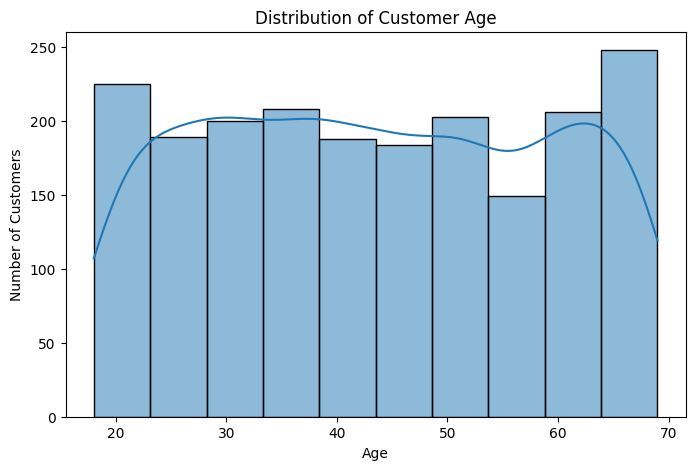

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=10,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

The customer base is distributed across a broad adult age range of 18–69, with customers represented fairly consistently across most age groups. The distribution does not show a strong concentration among younger adults. Customer representation is highest among the oldest age bracket (approximately 64–69), with close to 250 customers. A noticeable dip occurs in the mid-to-late 50s, where the number of customers falls before increasing again in the oldest age group.


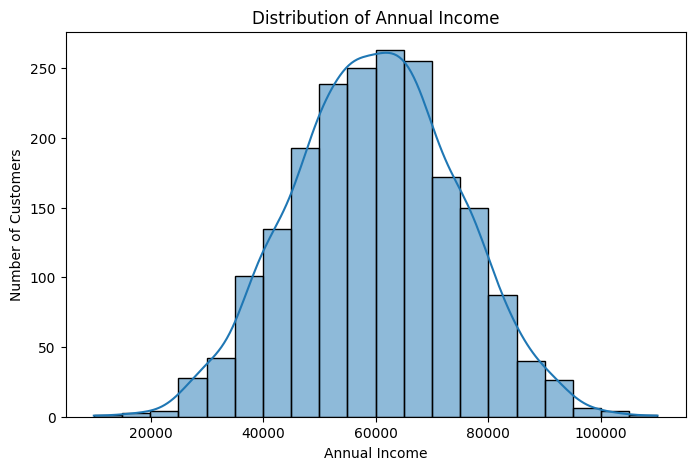

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Annual_Income"],
    bins=20,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()

Annual income is broadly centered around $60,000, with most customers concentrated in the middle-income range. The distribution appears approximately symmetric, with customer counts gradually declining toward both lower- and higher-income levels.

The largest concentration occurs around $60,000–$65,000, containing more than 250 customers. Relatively few customers have annual incomes below $25,000 or above $95,000, indicating that extreme income levels are uncommon in this customer base.


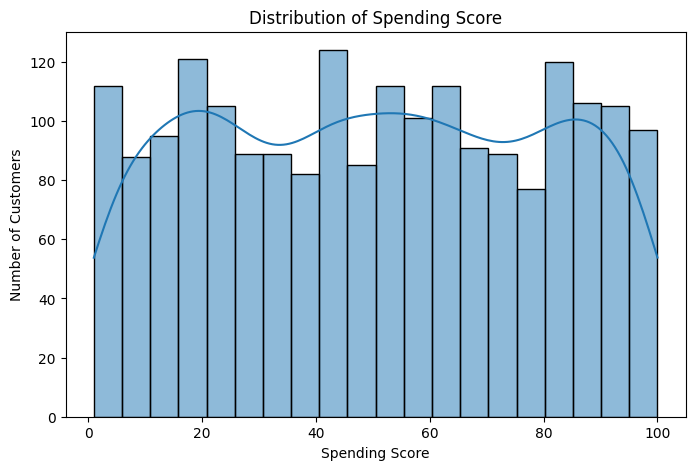

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Spending_Score"],
    bins=20,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

Spending scores span almost the entire 1–100 scale, indicating substantial variation in customer spending behavior rather than a strong concentration around a single score range. The largest individual concentration occurs around the 40–45 range, with slightly more than 120 customers.

The KDE curve suggests several mild areas of concentration around scores of approximately 20, 55, and 85, indicating that the customer base may contain distinct spending-behavior groups. These apparent clusters should be investigated further rather than assumed to represent clearly separate customer segments.


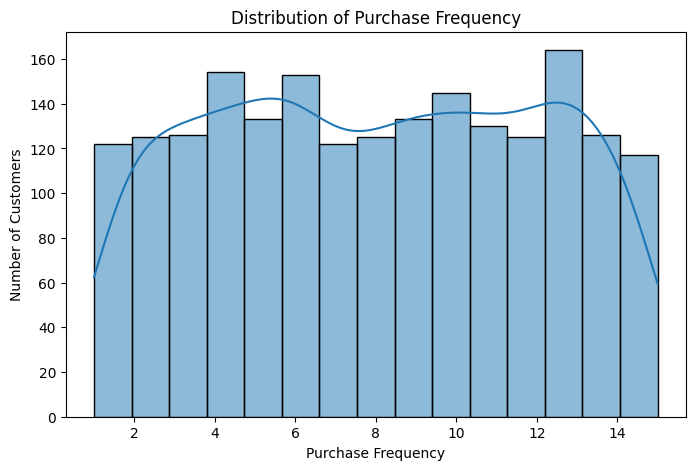

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Purchase_Frequency"],
    bins=15,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.show()

Purchase frequency is broadly distributed across the full range of 1–15 purchases, indicating substantial variation in how frequently customers engage with the company. The largest concentration appears around 12–13 purchases, where more than 160 customers are represented.

The KDE curve suggests a mild bimodal pattern, with a secondary concentration around 4–6 purchases. This indicates that the customer base may contain groups with relatively low and relatively high purchasing frequency, which can be investigated further when examining churn.


## Univariate Analysis of Categorical Features

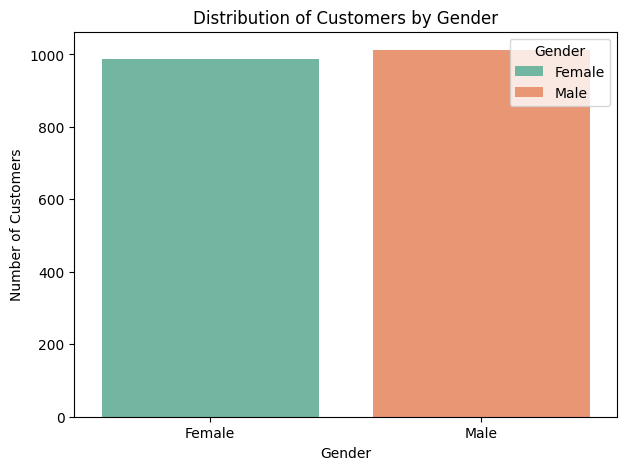

Gender
Male      50.6
Female    49.4
Name: proportion, dtype: float64


In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette="Set2",
    legend=True
)

plt.title("Distribution of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Gender")
plt.show()


# percenatges
print(
    df["Gender"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

The customer base is almost evenly divided between the two gender categories, indicating a highly balanced gender composition. Male customers form a marginally larger group, with just over 1,000 customers, while female customers account for just under 1,000.


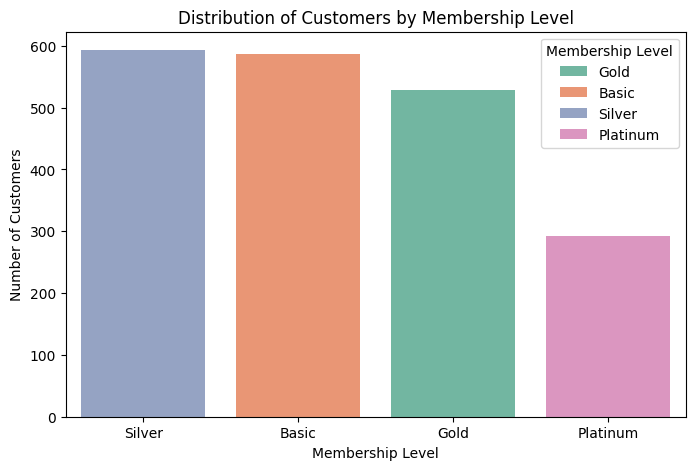

Membership_Level
Silver      29.65
Basic       29.30
Gold        26.45
Platinum    14.60
Name: proportion, dtype: float64


In [28]:
plt.figure(figsize=(8, 5))

order = df["Membership_Level"].value_counts().index

sns.countplot(
    data=df,
    x="Membership_Level",
    hue="Membership_Level",
    order=order,
    palette="Set2",
    legend=True
)

plt.title("Distribution of Customers by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Number of Customers")
plt.legend(title="Membership Level")
plt.show()

print(
    df["Membership_Level"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

Silver is the most populated membership tier, with just under 600 customers. Basic and Gold also have substantial representation, each exceeding 500 customers.

Platinum is the least represented tier, with just under 300 customers—approximately half the size of the Silver membership group. Overall, the customer base is concentrated more heavily in the Basic, Silver, and Gold tiers than in Platinum.



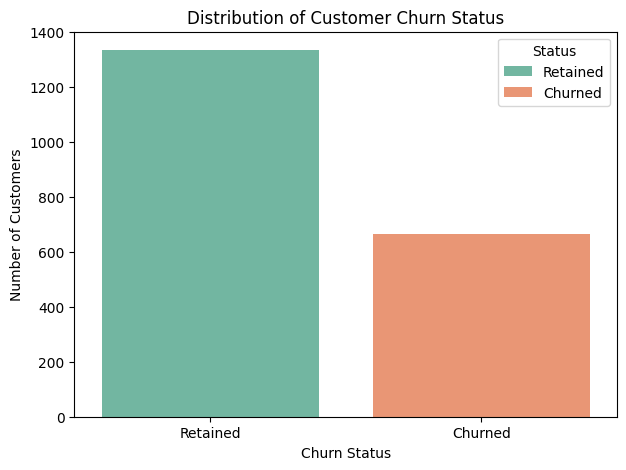

Churn_Status
0    66.75
1    33.25
Name: proportion, dtype: float64


In [29]:
churn_labels = {
    0: "Retained",
    1: "Churned"
}

churn_data = df.copy()
churn_data["Churn_Label"] = churn_data["Churn_Status"].map(churn_labels)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=churn_data,
    x="Churn_Label",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Distribution of Customer Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.legend(title="Status")
plt.show()

print(
    df["Churn_Status"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

The majority of customers are retained, with 1,335 customers (66.75%) remaining active compared with 665 customers (33.25%) who have churned. Thus, approximately one-third of the customer base has been lost.

Although retained customers form the clear majority, the churned segment is substantial enough to represent a significant business problem. This distribution also provides an important baseline for comparing churn rates across customer characteristics in the next stage of the analysis.


## Bivariate Analysis

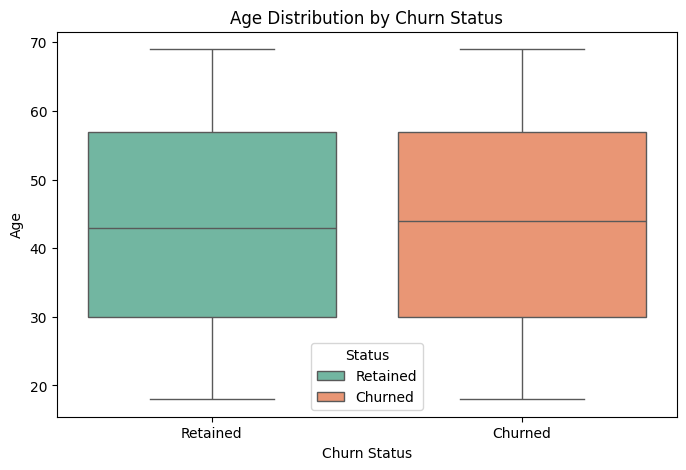

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Age",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Age")
plt.legend(title="Status")
plt.show()

/tmp/ipykernel_4604/1310000878.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Status")


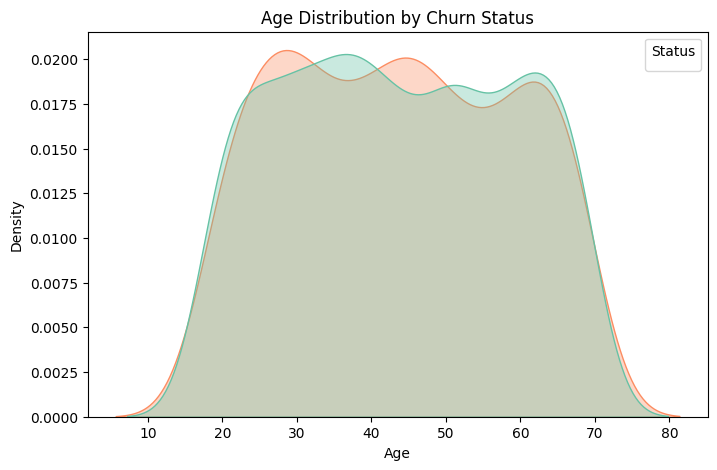

In [31]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Age",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend(title="Status")
plt.show()

The box plot shows that the age distributions of retained and churned customers are highly similar. Both groups have a median age in the early 40s, with the middle 50% of customers spanning approximately ages 30–57, while their overall ranges are also nearly identical.

The KDE plot reinforces this substantial overlap, with retained and churned customers exhibiting very similar density patterns across the adult age range. Although minor differences appear at individual age ranges, there is no obvious age region where one churn group is substantially more concentrated than the other.


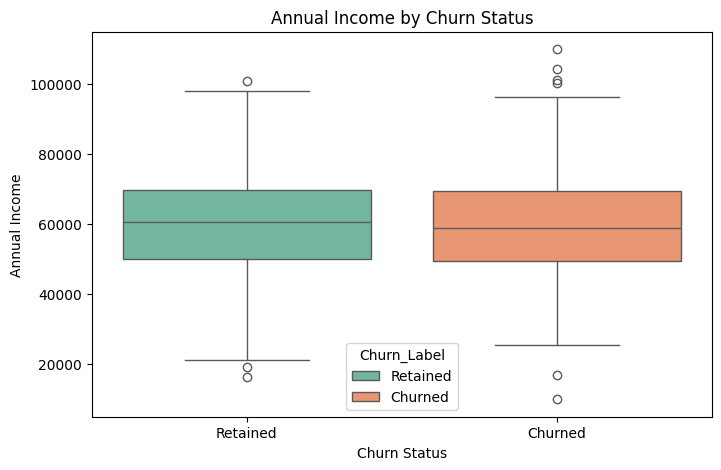

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Annual_Income",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Annual Income by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Annual Income")
plt.show()

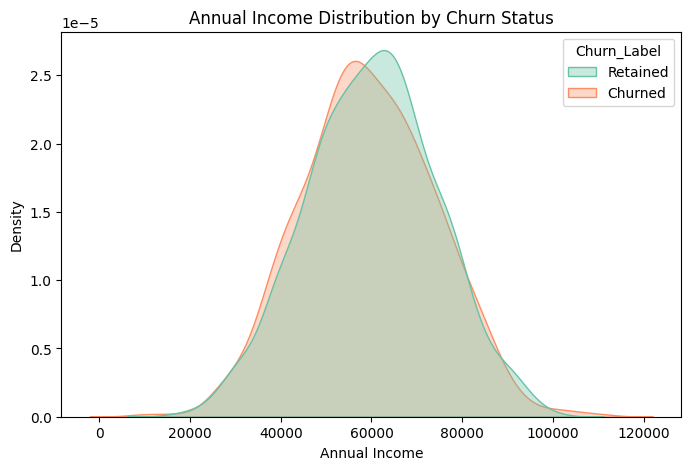

In [34]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Annual_Income",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Annual Income Distribution by Churn Status")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.show()

The box plot shows that retained and churned customers have very similar annual income distributions. Both groups have a median income of approximately `$`60,000, while the middle 50\% of customers in each group falls broadly within the $50,000–$70,000 range.

The KDE plot reinforces this substantial overlap, with both groups exhibiting similar distribution shapes and a central concentration around $60,000. Based on these visual comparisons, annual income does not show an obvious strong association with churn in this dataset.


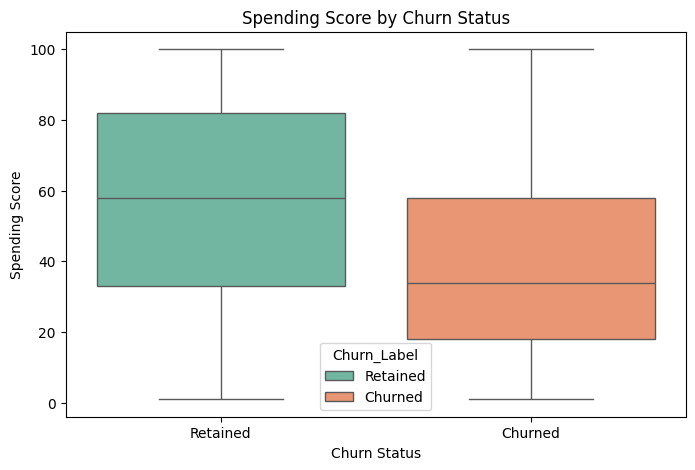

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Spending_Score",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Spending Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Spending Score")
plt.show()

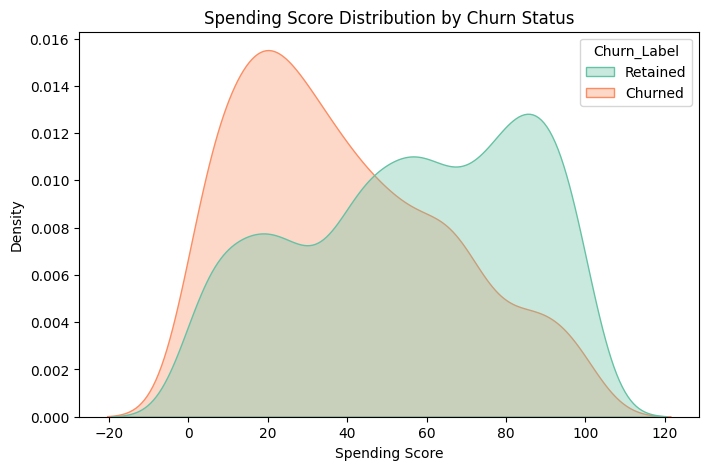

In [36]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Spending_Score",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Spending Score Distribution by Churn Status")
plt.xlabel("Spending Score")
plt.ylabel("Density")
plt.show()

The box plot shows a clear difference in spending behavior between the two groups. Retained customers have a substantially higher median Spending Score of approximately 60, compared with roughly 34 among churned customers.

The KDE plot reinforces this separation, with churned customers strongly concentrated toward the lower end of the spending scale, particularly around a score of 20. Retained customers show a broader distribution with considerably greater concentration in the upper half of the scale, suggesting that lower spending engagement is strongly associated with customer churn.


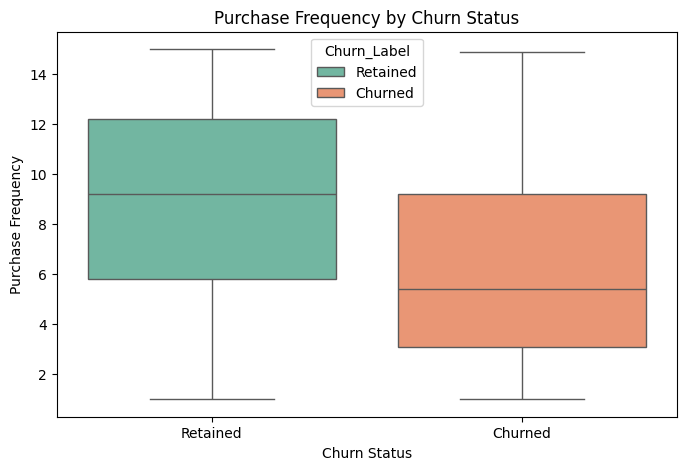

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Purchase_Frequency",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Purchase Frequency by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Purchase Frequency")
plt.show()

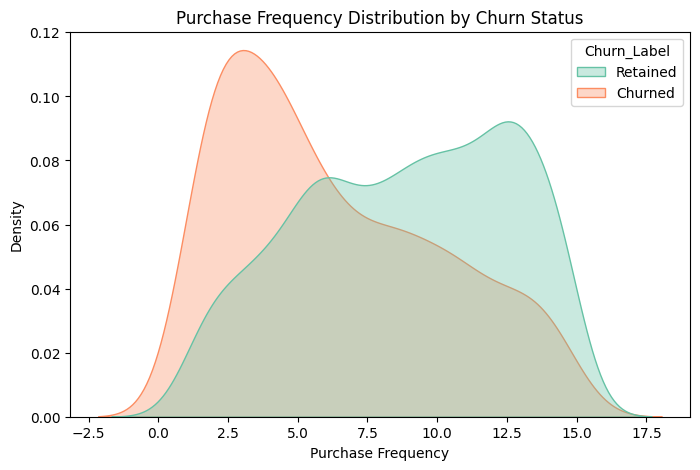

In [38]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Purchase_Frequency",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Purchase Frequency Distribution by Churn Status")
plt.xlabel("Purchase Frequency")
plt.ylabel("Density")
plt.show()

The box plot shows a noticeable difference in purchasing behavior between the two groups. Retained customers have a higher median purchase frequency of approximately 9 purchases, compared with roughly 5–6 purchases among churned customers.

The KDE plot reinforces this separation, with churned customers concentrated toward the lower end of the frequency range and a prominent peak around 3 purchases. Retained customers are more widely distributed across higher activity levels, with additional concentrations around 6 and 12–13 purchases, suggesting that lower purchase frequency is strongly associated with customer churn.


In [40]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn_Status"],
    normalize="index"
) * 100

print(gender_churn)

Churn_Status          0          1
Gender                            
Female        64.979757  35.020243
Male          68.478261  31.521739


<Figure size 800x500 with 0 Axes>

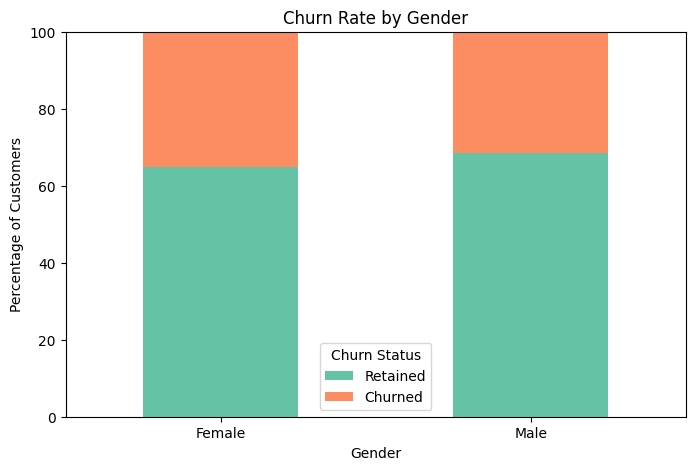

In [41]:
plt.figure(figsize=(8, 5))

gender_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=sns.color_palette("Set2", 2)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customers")
plt.legend(
    title="Churn Status",
    labels=["Retained", "Churned"]
)

plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

Female customers have a higher observed churn rate than male customers, with 35.02% of female customers churned compared with 31.52% of male customers. This represents a difference of approximately 3.5 percentage points.

The difference suggests a modest association between gender and churn, but the gap is considerably smaller than the behavioral differences observed for Spending Score and Purchase Frequency. Gender therefore appears to be a weaker differentiating factor in this dataset based on the initial descriptive analysis.


In [42]:
membership_churn = pd.crosstab(
    df["Membership_Level"],
    df["Churn_Status"],
    normalize="index"
) * 100

print(membership_churn)

Churn_Status              0          1
Membership_Level                      
Basic             65.870307  34.129693
Gold              65.784499  34.215501
Platinum          66.780822  33.219178
Silver            68.465430  31.534570


<Figure size 800x500 with 0 Axes>

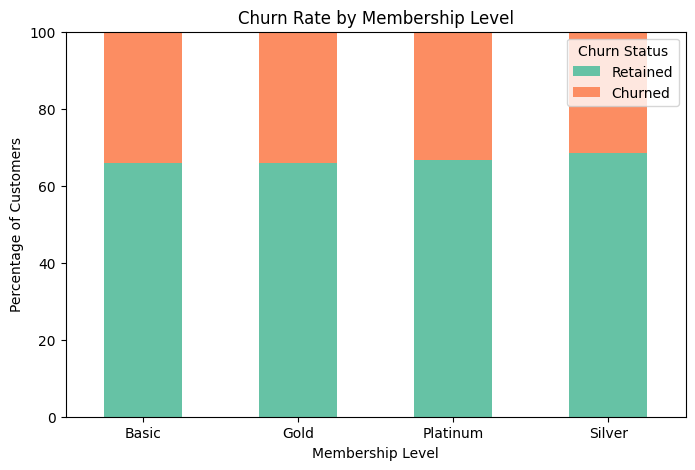

In [43]:
plt.figure(figsize=(8, 5))

membership_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=sns.color_palette("Set2", 2)
)

plt.title("Churn Rate by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Percentage of Customers")
plt.legend(
    title="Churn Status",
    labels=["Retained", "Churned"]
)

plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

In [44]:
membership_churn_rate = (
    df.groupby("Membership_Level")["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
)

print(membership_churn_rate)

Membership_Level
Basic       34.13
Gold        34.22
Platinum    33.22
Silver      31.53
Name: Churn_Status, dtype: float64


Churn rates are relatively consistent across all four membership levels, ranging from 31.53% for Silver customers to 34.22% for Gold customers. The difference between the highest and lowest churn rates is only 2.69 percentage points.

This indicates that membership level shows only a weak visible association with churn in this dataset. Although Silver customers have the lowest observed churn rate and Gold customers the highest, the relatively small differences suggest that membership tier alone does not strongly distinguish churned from retained customers.


## Detecting Outliers 

In [46]:
numerical_cols = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency"
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of potential outliers: {len(outliers)}")


Age
Q1: 30.00
Q3: 57.00
IQR: 27.00
Lower bound: -10.50
Upper bound: 97.50
Number of potential outliers: 0

Annual_Income
Q1: 49818.50
Q3: 69631.50
IQR: 19813.00
Lower bound: 20099.00
Upper bound: 99351.00
Number of potential outliers: 9

Spending_Score
Q1: 25.00
Q3: 76.00
IQR: 51.00
Lower bound: -51.50
Upper bound: 152.50
Number of potential outliers: 0

Purchase_Frequency
Q1: 4.60
Q3: 11.50
IQR: 6.90
Lower bound: -5.75
Upper bound: 21.85
Number of potential outliers: 0


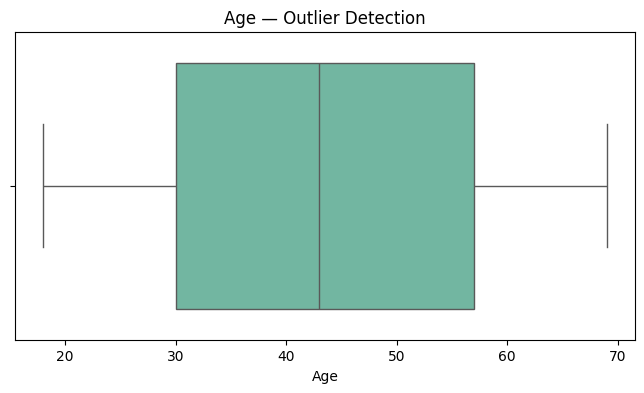

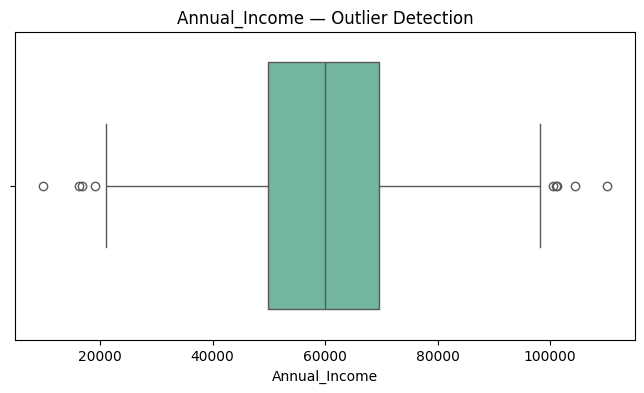

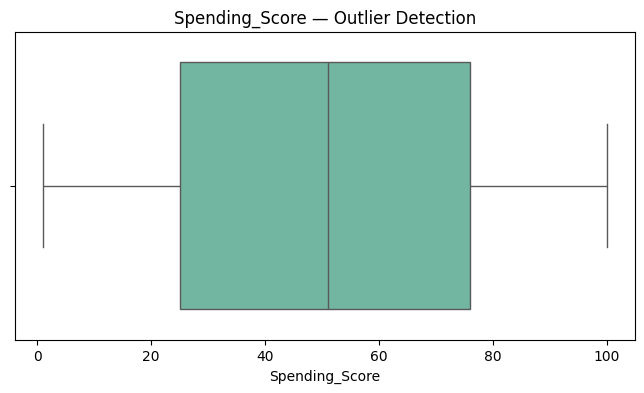

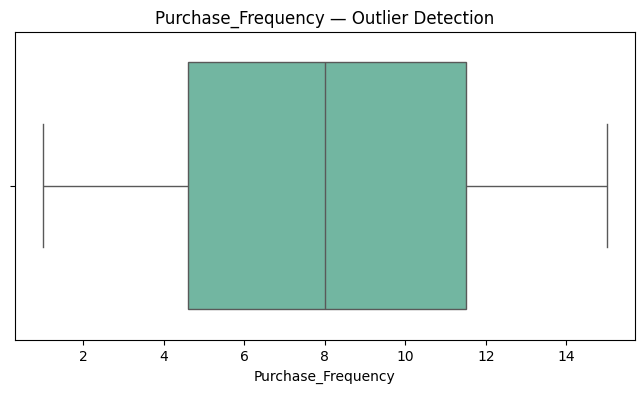

In [48]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col],
        color=sns.color_palette("Set2")[0]
    )

    plt.title(f"{col} — Outlier Detection")
    plt.xlabel(col)
    plt.show()

In [54]:
Q1 = df["Annual_Income"].quantile(0.25)
Q3 = df["Annual_Income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

income_outliers = df[
    (df["Annual_Income"] < lower_bound) |
    (df["Annual_Income"] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total potential outliers:", len(income_outliers))

Lower bound: 20099.0
Upper bound: 99351.0
Total potential outliers: 9


In [55]:
low_income_outliers = df[df["Annual_Income"] < lower_bound]
high_income_outliers = df[df["Annual_Income"] > upper_bound]

print("Low-income outliers:", len(low_income_outliers))
print("High-income outliers:", len(high_income_outliers))

Low-income outliers: 4
High-income outliers: 5


In [56]:
print("LOW-INCOME OUTLIERS")
display(
    low_income_outliers[
        [
            "CustomerID",
            "Name",
            "Age",
            "Gender",
            "Annual_Income",
            "Spending_Score",
            "Membership_Level",
            "Purchase_Frequency",
            "Churn_Status"
        ]
    ].sort_values("Annual_Income")
)

print("\nHIGH-INCOME OUTLIERS")
display(
    high_income_outliers[
        [
            "CustomerID",
            "Name",
            "Age",
            "Gender",
            "Annual_Income",
            "Spending_Score",
            "Membership_Level",
            "Purchase_Frequency",
            "Churn_Status"
        ]
    ].sort_values("Annual_Income", ascending=False)
)

LOW-INCOME OUTLIERS


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
141,CUST1141,Abigail Wheeler,49,Female,9857,13,Basic,3.1,1
1903,CUST2903,Jamie Weiss,65,Male,16331,81,Silver,11.7,0
1025,CUST2025,Kristen Wells,49,Female,16811,78,Silver,1.5,1
554,CUST1554,Barbara Scott,20,Male,19102,88,Gold,1.6,0



HIGH-INCOME OUTLIERS


,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status
1542,CUST2542,Brittany Brown,36,Male,110053,6,Silver,11.7,1
1500,CUST2500,Melinda Riley,46,Male,104486,24,Gold,4.8,1
1551,CUST2551,Lauren Wang,61,Female,101172,61,Gold,14.8,1
995,CUST1995,Theresa Sandoval,37,Male,101026,85,Basic,1.7,0
1529,CUST2529,Gregory White,35,Female,100425,53,Silver,14.0,1


The IQR method identified 9 potential outliers in Annual_Income: 4 below the lower bound of `$`20,099 and 5 above the upper bound of `$`99,351. Their incomes range from `$`9,857 to `$`110,053, making them statistically unusual within this customer population.

Inspection of the associated customer records revealed no obvious data-entry errors or implausible values. The extreme incomes are therefore treated as valid observations rather than errors, and all 9 customers are retained for subsequent analysis.


## Feature Engineering

### Feature 1

In [57]:
df["Engagement_Score"] = (
    df["Spending_Score"] / 100 +
    df["Purchase_Frequency"] / 15
) / 2

df["Engagement_Score"].describe()

count    2000.000000
mean        0.519029
std         0.198349
min         0.041667
25%         0.375000
50%         0.513333
75%         0.666667
max         0.995000
Name: Engagement_Score, dtype: float64

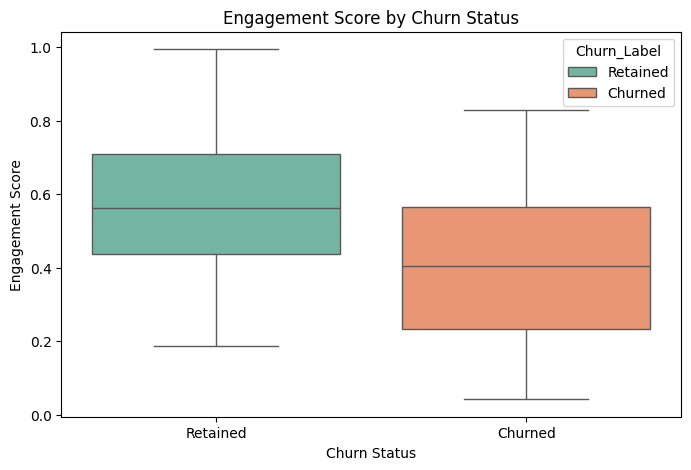

In [59]:
churn_data = df.copy()

churn_data["Churn_Label"] = churn_data["Churn_Status"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Engagement_Score",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Engagement Score by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Engagement Score")
plt.show()

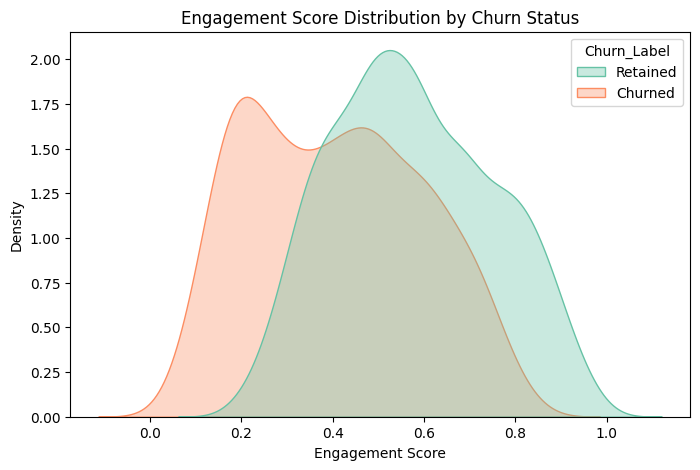

In [60]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Engagement_Score",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Engagement Score Distribution by Churn Status")
plt.xlabel("Engagement Score")
plt.ylabel("Density")
plt.show()

The box plot shows that retained customers have a higher median Engagement Score of approximately 0.55 compared with roughly 0.40 among churned customers. This indicates that retained customers generally exhibit stronger combined spending and purchasing activity.

The KDE plot reinforces this separation, with churned customers concentrated toward lower engagement scores and a prominent peak around 0.20, while retained customers are more heavily concentrated toward the upper half of the scale. The results suggest that lower overall engagement is strongly associated with customer churn.


### Feature 2


In [69]:
df["Spending_Frequency_Gap"] = (
    (df["Spending_Score"] / 100)
    - (df["Purchase_Frequency"] / 15)
).abs()

In [70]:
df["Spending_Frequency_Gap"].describe()

count    2000.000000
mean        0.318068
std         0.229029
min         0.000000
25%         0.120000
50%         0.273333
75%         0.473333
max         0.963333
Name: Spending_Frequency_Gap, dtype: float64

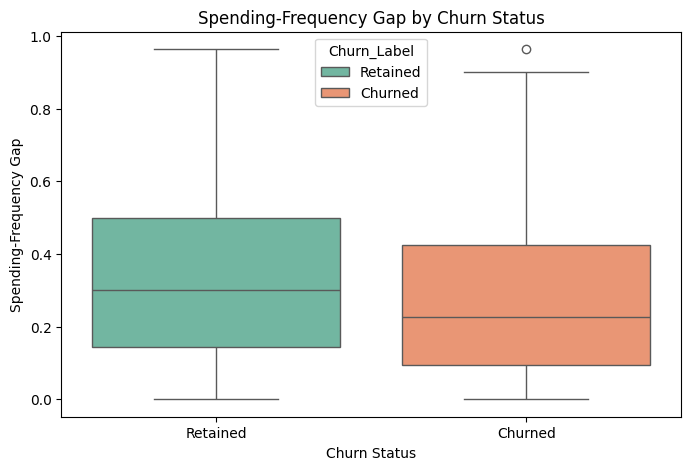

In [71]:
churn_data = df.copy()

churn_data["Churn_Label"] = churn_data["Churn_Status"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Spending_Frequency_Gap",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Spending-Frequency Gap by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Spending-Frequency Gap")
plt.show()

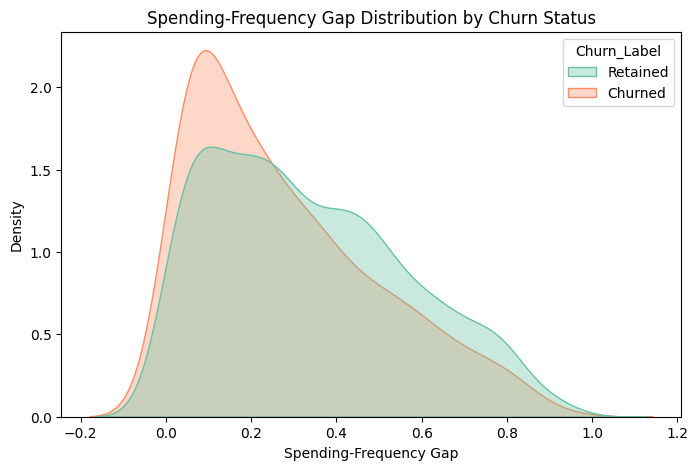

In [72]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Spending_Frequency_Gap",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Spending-Frequency Gap Distribution by Churn Status")
plt.xlabel("Spending-Frequency Gap")
plt.ylabel("Density")
plt.show()

### Feature 3

In [73]:
df["Purchase_Frequency_Level"] = pd.cut(
    df["Purchase_Frequency"],
    bins=[0, 5, 10, 15],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [74]:
frequency_level_churn = (
    df.groupby("Purchase_Frequency_Level", observed=True)["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
)

print(frequency_level_churn)

Purchase_Frequency_Level
Low       55.65
Medium    29.09
High      19.66
Name: Churn_Status, dtype: float64


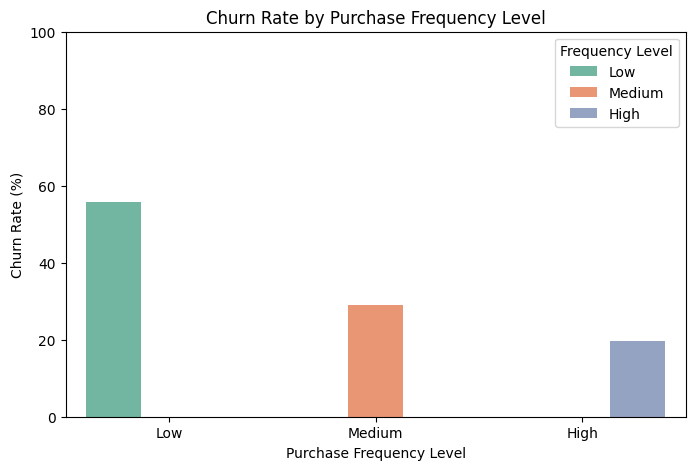

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=frequency_level_churn.index,
    y=frequency_level_churn.values,
    hue=frequency_level_churn.index,
    palette="Set2",
    legend=True
)

plt.title("Churn Rate by Purchase Frequency Level")
plt.xlabel("Purchase Frequency Level")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Frequency Level")
plt.show()

Churn varies substantially across purchase-frequency levels. Customers in the Low-frequency group have a 55.65% churn rate, compared with 29.09% among Medium-frequency customers and only 19.66% among High-frequency customers.

The results show a strong inverse relationship between purchasing frequency and churn: the Low-frequency segment has a churn rate nearly three times that of the High-frequency segment. This identifies infrequent purchasers as a particularly important customer group for retention efforts.


### Feature 4

In [76]:
df["Spending_Segment"] = pd.cut(
    df["Spending_Score"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)


In [77]:
spending_segment_churn = (
    df.groupby("Spending_Segment", observed=True)["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
)

print(spending_segment_churn)

Spending_Segment
Low       49.18
Medium    32.93
High      17.66
Name: Churn_Status, dtype: float64


Churn varies substantially across spending segments. Customers in the Low-spending group have a 49.18% churn rate, compared with 32.93% among Medium-spending customers and only 17.66% among High-spending customers.

The churn rate decreases consistently as spending engagement increases, with Low-spending customers experiencing nearly three times the churn rate of High-spending customers. This identifies low-spending customers as another high-risk segment that could be prioritized for retention efforts.


### Feature 5

In [78]:
df["Engagement_Segment"] = pd.cut(
    df["Engagement_Score"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [79]:
engagement_segment_churn = (
    df.groupby("Engagement_Segment", observed=True)["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
)

print(engagement_segment_churn)

Engagement_Segment
Low       71.62
Medium    29.25
High      14.26
Name: Churn_Status, dtype: float64


Churn varies dramatically across the three engagement segments. Low-engagement customers have a 71.62% churn rate, compared with 29.25% among Medium-engagement customers and only 14.26% among High-engagement customers.

The sharp decline in churn as engagement increases indicates that the combined Engagement Score captures a substantial difference between customer groups. In particular, Low-engagement customers represent a high-risk segment that could warrant immediate retention attention.


### Feature 6

In [80]:
membership_map = {
    "Basic": 1,
    "Silver": 2,
    "Gold": 3,
    "Platinum": 4
}

df["Membership_Score"] = df["Membership_Level"].map(membership_map)

In [81]:
df[
    ["Membership_Level", "Membership_Score"]
].drop_duplicates().sort_values("Membership_Score")

,Membership_Level,Membership_Score
1,Basic,1
2,Silver,2
0,Gold,3
3,Platinum,4


In [83]:
df

,CustomerID,Name,Age,Gender,Annual_Income,Spending_Score,Membership_Level,Purchase_Frequency,Churn_Status,Engagement_Score,Spending_Frequency_Gap,Purchase_Frequency_Level,Spending_Segment,Engagement_Segment,Membership_Score
0,CUST1000,Connor Rowland,40,Female,52777,27,Gold,5.2,0,0.308333,0.076667,Medium,Low,Low,3
1,CUST1001,Cameron Miles MD,28,Female,65910,84,Basic,12.2,0,0.826667,0.026667,High,High,High,1
2,CUST1002,Dennis Price,63,Male,56731,51,Silver,2.9,1,0.351667,0.316667,Low,Medium,Medium,2
3,CUST1003,Jessica Jones,23,Female,40559,56,Platinum,11.1,0,0.650000,0.180000,High,Medium,Medium,4
4,CUST1004,Kevin Bauer,38,Male,79675,74,Basic,10.7,0,0.726667,0.026667,High,High,High,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CUST2995,Dr. Gina Ferguson MD,20,Male,62280,37,Basic,12.4,0,0.598333,0.456667,High,Medium,Medium,1
1996,CUST2996,Jessica Nelson,30,Male,49876,91,Basic,6.8,0,0.681667,0.456667,Medium,High,High,1
1997,CUST2997,Joy Cruz,35,Female,76229,70,Silver,12.7,0,0.773333,0.146667,High,High,High,2
1998,CUST2998,Kelly Mendoza,67,Male,40169,40,Basic,14.0,1,0.666667,0.533333,High,Medium,High,1


### Feature 7

In [84]:
id_vars = ["Spending_Segment", "Purchase_Frequency_Level"]

df["Customer_Behavior_Type"] = (
    df["Spending_Segment"].astype(str)
    + " Spending - "
    + df["Purchase_Frequency_Level"].astype(str)
    + " Frequency"
)

In [85]:
print(df["Customer_Behavior_Type"].value_counts())

Customer_Behavior_Type
High Spending - High Frequency        256
Medium Spending - Medium Frequency    243
Low Spending - Medium Frequency       242
High Spending - Medium Frequency      237
Low Spending - High Frequency         230
Medium Spending - High Frequency      226
Medium Spending - Low Frequency       196
Low Spending - Low Frequency          195
High Spending - Low Frequency         175
Name: count, dtype: int64


In [86]:
behavior_churn = (
    df.groupby("Customer_Behavior_Type")["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(behavior_churn)

Customer_Behavior_Type
Low Spending - Low Frequency          98.46
Medium Spending - Low Frequency       38.27
Medium Spending - Medium Frequency    32.51
Low Spending - Medium Frequency       29.75
Medium Spending - High Frequency      28.76
Low Spending - High Frequency         27.83
High Spending - Low Frequency         27.43
High Spending - Medium Frequency      24.89
High Spending - High Frequency         4.30
Name: Churn_Status, dtype: float64


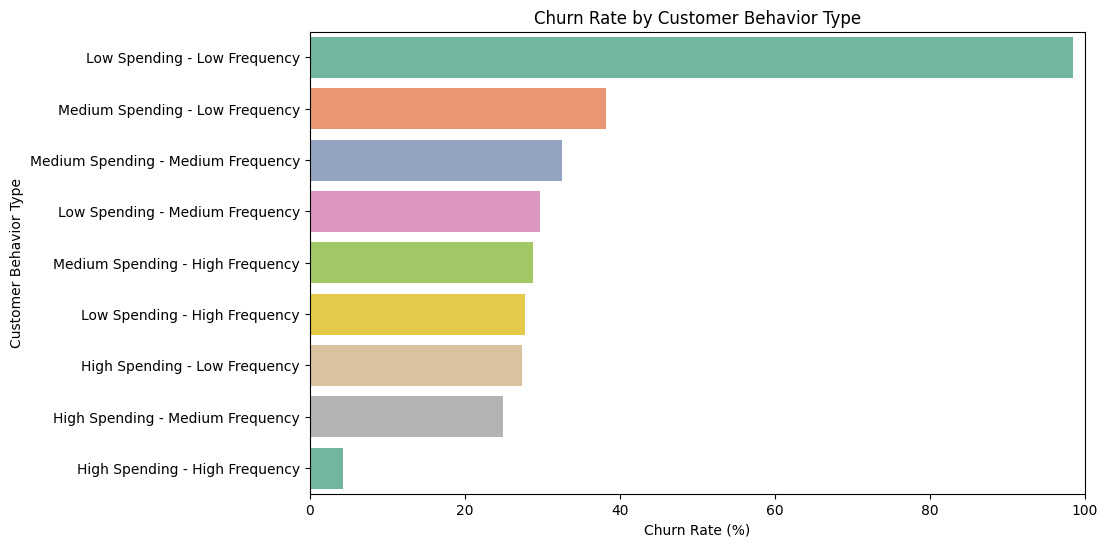

In [87]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=behavior_churn.values,
    y=behavior_churn.index,
    hue=behavior_churn.index,
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by Customer Behavior Type")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Behavior Type")
plt.xlim(0, 100)
plt.show()

Churn varies dramatically across the combined spending and purchasing-frequency profiles. The Low Spending–Low Frequency group has an exceptionally high churn rate of 98.46%, while the High Spending–High Frequency group has a churn rate of only 4.30%.

The results suggest that the combination of spending intensity and purchase frequency provides substantially more differentiation than either characteristic considered in isolation. Customers who are both low-spending and infrequent purchasers form an especially high-risk segment, whereas highly active, high-spending customers show very strong retention.


### Feature 8 

In [89]:
income_q1 = df["Annual_Income"].quantile(0.25)
income_q3 = df["Annual_Income"].quantile(0.75)

df["Income_Segment"] = pd.cut(
    df["Annual_Income"],
    bins=[-float("inf"), income_q1, income_q3, float("inf")],
    labels=["Low", "Middle", "High"]
)

In [90]:
print(df["Income_Segment"].value_counts())

Income_Segment
Middle    1000
Low        500
High       500
Name: count, dtype: int64


In [91]:
income_segment_churn = (
    df.groupby("Income_Segment", observed=True)["Churn_Status"]
      .mean()
      .mul(100)
      .round(2)
)

print(income_segment_churn)

Income_Segment
Low       34.0
Middle    33.3
High      32.4
Name: Churn_Status, dtype: float64


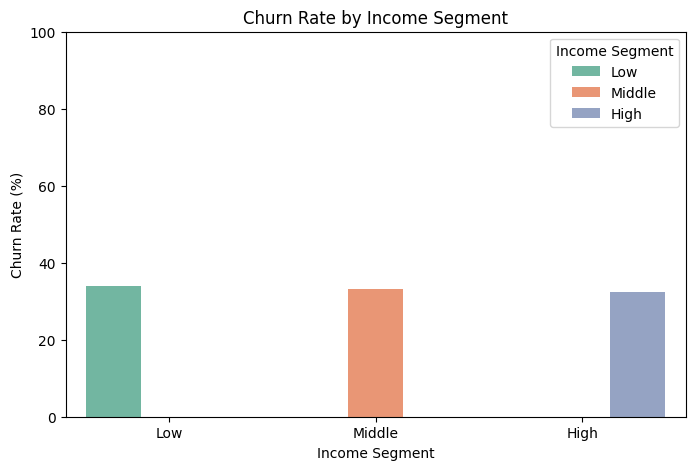

In [92]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=income_segment_churn.index,
    y=income_segment_churn.values,
    hue=income_segment_churn.index,
    palette="Set2",
    legend=True
)

plt.title("Churn Rate by Income Segment")
plt.xlabel("Income Segment")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.legend(title="Income Segment")
plt.show()

Churn rates are highly consistent across the three income segments, ranging from 32.40% among High-income customers to 34.00% among Low-income customers. The maximum difference between segments is only 1.60 percentage points.

This reinforces the earlier finding that annual income has little observable association with churn in this dataset. Segmenting customers by relative income therefore provides limited additional differentiation of churn risk.


### Feature 9

In [93]:
membership_normalized = (
    df["Membership_Score"] - 1
) / 3

df["Engagement_vs_Membership"] = (
    df["Engagement_Score"] - membership_normalized
)

In [94]:
df[
    [
        "Membership_Level",
        "Membership_Score",
        "Engagement_Score",
        "Engagement_vs_Membership"
    ]
].head(10)

,Membership_Level,Membership_Score,Engagement_Score,Engagement_vs_Membership
0,Gold,3,0.308333,-0.358333
1,Basic,1,0.826667,0.826667
2,Silver,2,0.351667,0.018333
3,Platinum,4,0.650000,-0.350000
4,Basic,1,0.726667,0.726667
5,Silver,2,0.290000,-0.043333
6,Silver,2,0.506667,0.173333
7,Silver,2,0.576667,0.243333
8,Platinum,4,0.860000,-0.140000
9,Gold,3,0.820000,0.153333


In [95]:
df["Engagement_vs_Membership"].describe()

count    2000.000000
mean        0.097863
std         0.395753
min        -0.918333
25%        -0.178333
50%         0.111667
75%         0.403333
max         0.995000
Name: Engagement_vs_Membership, dtype: float64

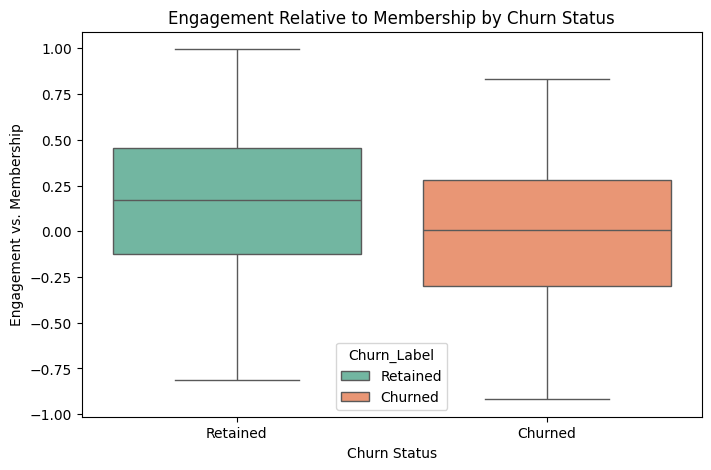

In [97]:
churn_data = df.copy()

churn_data["Churn_Label"] = churn_data["Churn_Status"].map({
    0: "Retained",
    1: "Churned"
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Engagement_vs_Membership",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Engagement Relative to Membership by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Engagement vs. Membership")
plt.show()

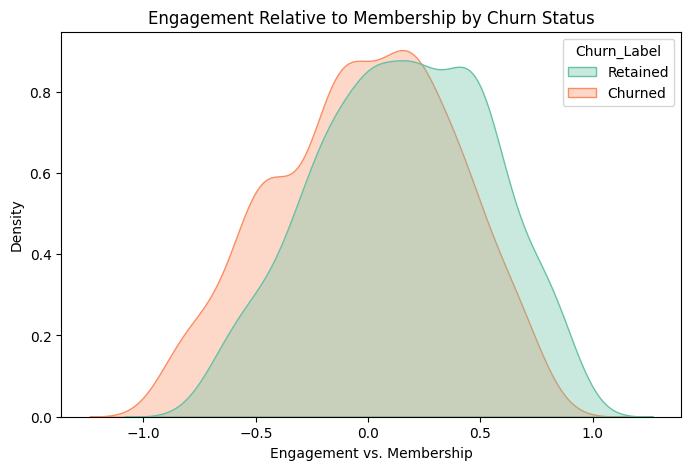

In [98]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Engagement_vs_Membership",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Engagement Relative to Membership by Churn Status")
plt.xlabel("Engagement vs. Membership")
plt.ylabel("Density")
plt.show()

### Feature 10

In [99]:
df["Customer_Value_Profile"] = (
    (df["Spending_Score"] / 100)
    + (df["Purchase_Frequency"] / 15)
    + ((df["Membership_Score"] - 1) / 3)
) / 3

In [100]:
df["Customer_Value_Profile"].describe()

count    2000.000000
mean        0.486408
std         0.176493
min         0.027778
25%         0.357500
50%         0.485556
75%         0.608889
max         0.971111
Name: Customer_Value_Profile, dtype: float64

In [101]:
churn_data = df.copy()

churn_data["Churn_Label"] = churn_data["Churn_Status"].map({
    0: "Retained",
    1: "Churned"
})

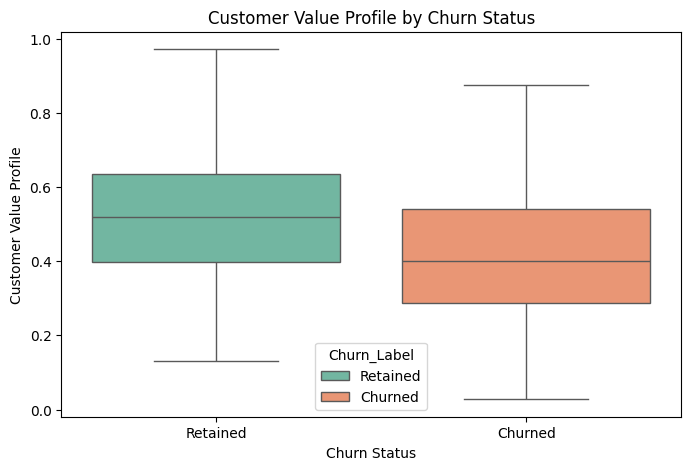

In [102]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=churn_data,
    x="Churn_Label",
    y="Customer_Value_Profile",
    hue="Churn_Label",
    palette="Set2",
    order=["Retained", "Churned"],
    legend=True
)

plt.title("Customer Value Profile by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Customer Value Profile")
plt.show()

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=churn_data,
    x="Customer_Value_Profile",
    hue="Churn_Label",
    hue_order=["Retained", "Churned"],
    palette="Set2",
    fill=True,
    common_norm=False,
    alpha=0.35
)

plt.title("Customer Value Profile Distribution by Churn Status")
plt.xlabel("Customer Value Profile")
plt.ylabel("Density")
plt.show()

The box plot shows that retained customers have a higher median Customer Value Profile of approximately 0.52 compared with around 0.40 among churned customers. This indicates that retained customers generally combine stronger spending activity, purchase frequency, and membership levels.

The KDE plot reinforces this pattern, with churned customers more concentrated toward lower profile scores and retained customers shifted toward higher values. Overall, a stronger combined customer profile is positively associated with retention in this dataset.


## Summary of Engineered Features


In [104]:
continuous_engineered = [
    "Engagement_Score",
    "Spending_Frequency_Gap",
    "Engagement_vs_Membership",
    "Customer_Value_Profile"
]

summary_continuous = []

for col in continuous_engineered:
    retained_median = df.loc[
        df["Churn_Status"] == 0, col
    ].median()

    churned_median = df.loc[
        df["Churn_Status"] == 1, col
    ].median()

    difference = retained_median - churned_median

    summary_continuous.append({
        "Feature": col,
        "Retained Median": round(retained_median, 3),
        "Churned Median": round(churned_median, 3),
        "Difference": round(difference, 3)
    })

continuous_summary = pd.DataFrame(summary_continuous)

print(continuous_summary)

                    Feature  Retained Median  Churned Median  Difference
0          Engagement_Score            0.563           0.403       0.160
1    Spending_Frequency_Gap            0.300           0.227       0.073
2  Engagement_vs_Membership            0.170           0.008       0.162
3    Customer_Value_Profile            0.518           0.401       0.117


In [105]:
categorical_engineered = [
    "Purchase_Frequency_Level",
    "Spending_Segment",
    "Engagement_Segment",
    "Customer_Behavior_Type",
    "Income_Segment"
]

for col in categorical_engineered:

    print(f"\n{'=' * 50}")
    print(col)
    print(f"{'=' * 50}")

    result = (
        df.groupby(col, observed=True)["Churn_Status"]
          .agg(["mean", "count"])
    )

    result["Churn_Rate_%"] = (
        result["mean"] * 100
    ).round(2)

    result = result.drop(columns="mean")

    print(result.sort_values("Churn_Rate_%", ascending=False))


Purchase_Frequency_Level
                          count  Churn_Rate_%
Purchase_Frequency_Level                     
Low                         566         55.65
Medium                      722         29.09
High                        712         19.66

Spending_Segment
                  count  Churn_Rate_%
Spending_Segment                     
Low                 667         49.18
Medium              665         32.93
High                668         17.66

Engagement_Segment
                    count  Churn_Rate_%
Engagement_Segment                     
Low                   370         71.62
Medium               1118         29.25
High                  512         14.26

Customer_Behavior_Type
                                    count  Churn_Rate_%
Customer_Behavior_Type                                 
Low Spending - Low Frequency          195         98.46
Medium Spending - Low Frequency       196         38.27
Medium Spending - Medium Frequency    243         32.51
Low Spending

In [106]:
membership_score_churn = (
    df.groupby("Membership_Score")["Churn_Status"]
      .agg(["mean", "count"])
)

membership_score_churn["Churn_Rate_%"] = (
    membership_score_churn["mean"] * 100
).round(2)

print(membership_score_churn)

                      mean  count  Churn_Rate_%
Membership_Score                               
1                 0.341297    586         34.13
2                 0.315346    593         31.53
3                 0.342155    529         34.22
4                 0.332192    292         33.22


## Business Insights

## Conclusion

This exploratory analysis indicates that customer churn is more strongly associated with **customer engagement and purchasing behavior** than with demographics, income, or membership level.

The overall churn rate in the dataset is **33.25%**. Behavioral segmentation reveals the clearest differences: customers with **low purchase frequency** have a 55.65% churn rate, while high-frequency customers have a 19.66% churn rate. Similarly, churn falls from **49.18% among low-spending customers** to **17.66% among high-spending customers**.

The strongest distinction emerges when spending and purchase frequency are considered together. Customers classified as **Low Spending–Low Frequency have a 98.46% churn rate**, compared with only **4.30% among High Spending–High Frequency customers**. The engineered Engagement Score also shows a substantial separation, with churn rates of **71.62% for low-engagement customers** versus **14.26% for high-engagement customers**.

In contrast, demographic and financial characteristics show considerably weaker differences. Gender has only a 3.50-percentage-point difference in churn rates, income segments differ by just 1.60 percentage points, and membership levels differ by only 2.69 percentage points.

Overall, the analysis suggests that **declining customer activity and engagement should be the primary focus of churn monitoring and retention efforts**. The data science team should therefore consider features related to spending behavior, purchase frequency, and combined engagement when developing the subsequent churn-prediction model.

It is important to note that these findings describe **associations rather than causal relationships**. Further statistical testing and predictive modeling would be required to determine which variables provide independent predictive value and how accurately future churn can be predicted.
